In [259]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt

In [260]:
df = pd.read_csv("D:\VS CODE\ML_Projects\House Price Prediction Dataset.csv")

In [261]:
df.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


In [262]:
if 'Id' in df:
    df.drop("Id",axis=1,inplace=True)

In [263]:
X=df.drop("Price",axis=1)
X.head()

,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage
0,1360,5,4,3,1970,Downtown,Excellent,No
1,4272,5,4,3,1958,Downtown,Excellent,No
2,3592,2,2,3,1938,Downtown,Good,No
3,966,4,2,2,1902,Suburban,Fair,Yes
4,4926,1,4,2,1975,Downtown,Fair,Yes


In [264]:
Y=df["Price"]

In [265]:
df.isna().sum()

Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64

In [266]:
cat1=X.iloc[:,5:]

In [267]:
dummies = pd.get_dummies(cat1,dtype=int,drop_first=True)
dummies

,Location_Rural,Location_Suburban,Location_Urban,Condition_Fair,Condition_Good,Condition_Poor,Garage_Yes
0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0
2,0,0,0,0,1,0,0
3,0,1,0,1,0,0,1
4,0,0,0,1,0,0,1
...,...,...,...,...,...,...,...
1995,0,1,0,0,0,1,0
1996,0,1,0,0,0,1,1
1997,1,0,0,0,0,1,0
1998,0,0,1,0,0,0,1


In [268]:
X=X.drop(["Location","Garage","Condition"],axis=1)

In [269]:
X.head()

,Area,Bedrooms,Bathrooms,Floors,YearBuilt
0,1360,5,4,3,1970
1,4272,5,4,3,1958
2,3592,2,2,3,1938
3,966,4,2,2,1902
4,4926,1,4,2,1975


In [270]:
X=pd.concat([X,dummies],axis=1)
X.head()

,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location_Rural,Location_Suburban,Location_Urban,Condition_Fair,Condition_Good,Condition_Poor,Garage_Yes
0,1360,5,4,3,1970,0,0,0,0,0,0,0
1,4272,5,4,3,1958,0,0,0,0,0,0,0
2,3592,2,2,3,1938,0,0,0,0,1,0,0
3,966,4,2,2,1902,0,1,0,1,0,0,1
4,4926,1,4,2,1975,0,0,0,1,0,0,1


In [271]:
# from sklearn.preprocessing import LabelEncoder
# encoder = LabelEncoder()
# X['Condition'] = encoder.fit_transform(X["Condition"])

In [272]:
X.head()

,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location_Rural,Location_Suburban,Location_Urban,Condition_Fair,Condition_Good,Condition_Poor,Garage_Yes
0,1360,5,4,3,1970,0,0,0,0,0,0,0
1,4272,5,4,3,1958,0,0,0,0,0,0,0
2,3592,2,2,3,1938,0,0,0,0,1,0,0
3,966,4,2,2,1902,0,1,0,1,0,0,1
4,4926,1,4,2,1975,0,0,0,1,0,0,1


In [273]:
from sklearn.model_selection import train_test_split

In [274]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=23)

In [275]:
from sklearn.preprocessing import MinMaxScaler
sc=MinMaxScaler()

In [276]:
X_train=sc.fit_transform(X_train)
X_test=sc.transform(X_test)

In [277]:
from sklearn.ensemble import RandomForestRegressor
rfg_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    random_state=42
)

In [278]:
rfg_model.fit(X_train,Y_train)

RandomForestRegressor(n_estimators=300, random_state=42)

In [279]:
Y_pred=rfg_model.predict(X_test)

In [280]:
from sklearn.metrics import mean_absolute_error,r2_score
print(r2_score(Y_test,Y_pred))
print(mean_absolute_error(Y_test,Y_pred))

-0.07065810410483264
250142.11502499998


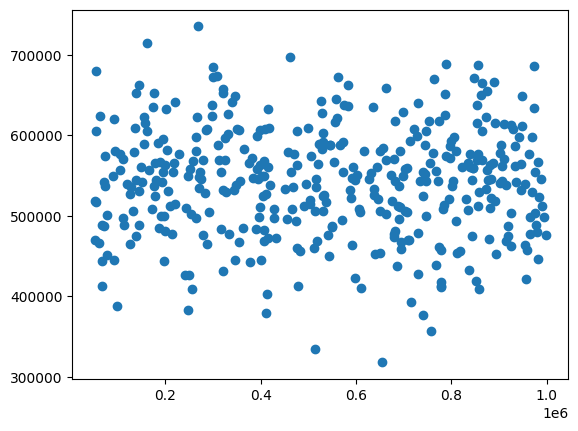

In [281]:
plt.scatter(Y_test,Y_pred)